## Analysis of an E-commerce Dataset Part 2

The goal of the second analysis task is to train linear regression models to predict users' ratings towards items. This involves a standard Data Science workflow: exploring data, building models, making predictions, and evaluating results. In this task, we will explore the impacts of feature selections and different sizes of training/testing data on the model performance. We will use another cleaned combined e-commerce sub-dataset that **is different from** the one in “Analysis of an E-commerce Dataset” task 1.

### Import Cleaned E-commerce Dataset
The csv file named 'cleaned_ecommerce_dataset.csv' is provided. You may need to use the Pandas method, i.e., `read_csv`, for reading it. After that, please print out its total length.

In [233]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn import linear_model
from sklearn.metrics import r2_score

import seaborn as sns
import matplotlib.pylab as plt
import matplotlib.pyplot as plt
%matplotlib inline

ds = '/Users/irfanakram/Documents/GitHub/Irfan6200/Portfolio Submission COMP6200/portfolio-part-2-IrfanA13/cleaned_ecommerce_dataset.csv'

In [234]:
#Printing out the total length
df = pd.read_csv(ds)
print(len(df))

2685


### Explore the Dataset

* Use the methods, i.e., `head()` and `info()`, to have a rough picture about the data, e.g., how many columns, and the data types of each column.
* As our goal is to predict ratings given other columns, please get the correlations between helpfulness/gender/category/review and rating by using the `corr()` method.

  Hints: To get the correlations between different features, you may need to first convert the categorical features (i.e., gender, category and review) into numerial values. For doing this, you may need to import `OrdinalEncoder` from `sklearn.preprocessing` (refer to the useful exmaples [here](https://pbpython.com/categorical-encoding.html))
* Please provide ___necessary explanations/analysis___ on the correlations, and figure out which are the ___most___ and ___least___ corrleated features regarding rating. Try to ___discuss___ how the correlation will affect the final prediction results, if we use these features to train a regression model for rating prediction. In what follows, we will conduct experiments to verify your hypothesis.

In [235]:
#Displaying the dataset.
df = pd.read_csv(ds)
df.head()

,userId,timestamp,review,item,rating,helpfulness,gender,category,item_id,item_price,user_city
0,4081,71900,Not always McCrap,McDonald's,4.0,3.0,M,Restaurants & Gourmet,41,30.74,4
1,4081,72000,I dropped the chalupa even before he told me to,Taco Bell,1.0,4.0,M,Restaurants & Gourmet,74,108.30,4
2,4081,72000,The Wonderful World of Wendy,Wendy's,5.0,4.0,M,Restaurants & Gourmet,84,69.00,4
3,4081,100399,They actually did it,"South Park: Bigger, Longer & Uncut",5.0,3.0,M,Movies,68,143.11,4
4,4081,100399,Hey! Gimme some pie!,American Pie,3.0,3.0,M,Movies,6,117.89,4


In [236]:
df = pd.read_csv(ds)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2685 entries, 0 to 2684
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   userId       2685 non-null   int64  
 1   timestamp    2685 non-null   int64  
 2   review       2685 non-null   object 
 3   item         2685 non-null   object 
 4   rating       2685 non-null   float64
 5   helpfulness  2685 non-null   float64
 6   gender       2685 non-null   object 
 7   category     2685 non-null   object 
 8   item_id      2685 non-null   int64  
 9   item_price   2685 non-null   float64
 10  user_city    2685 non-null   int64  
dtypes: float64(3), int64(4), object(4)
memory usage: 230.9+ KB


In [237]:
#Converting the string data (categorical column data for gender, category, and review into float values)
from sklearn.preprocessing import OrdinalEncoder

ord_enc = OrdinalEncoder()
df['gender_code'] = ord_enc.fit_transform(df[['gender']])
df['category_code'] = ord_enc.fit_transform(df[['category']])
df['review_code'] = ord_enc.fit_transform(df[['review']])

In [238]:
#Correlation between Rating and Helpfulness.
print(df['rating'].corr(df['helpfulness']))

-0.007523337726844546


##### Rating and Helpfulness Correlation Analysis: 
The correlation coefficient between rating and helpfulness is -0.007523337726844546. 

The negative correlation indicates that there might be a slight inverse relationship between rating and helpfulness - indicating as the numerical value of one increase, the value for the other decreases. 

As the correlation value is extremely close to zero, this indicates that the linear relationship between the two variables is very weak, suggesting that there's almost no linear association between the two variables.

In [202]:
#Correlation between Rating and Gender.
print(df['rating'].corr(df['gender_code']))

-0.03433661424208265


##### Rating and Gender Correlation Analysis: 
The correlation coefficient between rating and gender (gender_code) is -0.03433661424208265. 

The negative correlation indicates that there might be a slight inverse relationship between gender and rating - indicating as that the rating value associated with one gender can be slightly less than it is associated with the other gender.

As the correlation value is close to zero, this indicates that the linear relationship between the two variables is very weak, suggesting that there's almost no linear association between the two variables.

In [203]:
#Correlation between Rating and Category.
print(df['rating'].corr(df['category_code']))

-0.16315765340915653


##### Rating and Category Correlation Analysis: 
The correlation coefficient between rating and category(category_code) is -0.16315765340915653. 

The negative correlation indicates that there might be a slight inverse relationship between category and rating - indicating that the rating value associated with particular category column elements can be slightly less than it is associated with other category column elements.

As the correlation value is close to zero, this indicates that the linear relationship between the two variables is weak. The correlation value is still the highest amongst the variables tested previously, so the relationship is relatively stronger, but it is still close to zero and hence weak.

In [204]:
#Correlation between Rating and Review.
print(df['rating'].corr(df['review_code']))

-0.036118386552122385


##### Rating and Review Correlation Analysis: 
The correlation coefficient between rating and review(review_code) is -0.036118386552122385. 

The negative correlation indicates that there might be a slight inverse relationship between review and rating - indicating that the rating value associated with particular review column elements can be slightly less than it is associated with other elements.

As the correlation value is close to zero, this indicates that the linear relationship between the two variables is very weak, suggesting that there's almost no linear association between the two variables.

### Split Training and Testing Data
* Machine learning models are trained to help make predictions for the future. Normally, we need to randomly split the dataset into training and testing sets, where we use the training set to train the model, and then leverage the well-trained model to make predictions on the testing set.
* To further investigate whether the size of the training/testing data affects the model performance, please random split the data into training and testing sets with different sizes:
    * Case 1: training data containing 10% of the entire data;
    * Case 2: training data containing 90% of the entire data.
* Print the shape of training and testing sets in the two cases.

In [239]:
#Case 1
train1, test1 = train_test_split(df, test_size=0.9, random_state=42)
print(train1.shape)
print(test1.shape)

#Case 2
train2, test2 = train_test_split(df, test_size=0.1, random_state=112)
print(train2.shape)
print(test2.shape)

(268, 14)
(2417, 14)
(2416, 14)
(269, 14)


### Train Linear Regression Models with Feature Selection under Cases 1 & 2
* When training a machine learning model for prediction, we may need to select the most important/correlated input features for more accurate results.
* To investigate whether feature selection affects the model performance, please select two most correlated features and two least correlated features from helpfulness/gender/category/review regarding rating, respectively.
* Train four linear regression models by following the conditions:
    - (model-a) using the training/testing data in case 1 with two most correlated input features
    - (model-b) using the training/testing data in case 1 with two least correlated input features
    - (model-c) using the training/testing data in case 2 with two most correlated input features
    - (model-d) using the training/testing data in case 2 with two least correlated input features
* By doing this, we can verify the impacts of the size of traing/testing data on the model performance via comparing model-a and model-c (or model-b and model-d); meanwhile the impacts of feature selection can be validated via comparing model-a and model-b (or model-c and model-d).    

In [206]:
# model-a - Category & review, rating - case 1

X_train_a = train1[['category_code','review_code']]
y_train_a = train1[['rating']]

X_test_a = test1[['category_code','review_code']]
y_test_a = test1[['rating']]

reg = linear_model.LinearRegression()
reg.fit(X_train_a,y_train_a)
predicted = reg.predict(X_test_a)

In [207]:
# model-b - Helpfulness & gender, rating - case 1

X_train_b = train1[['helpfulness','gender_code']]
y_train_b = train1[['rating']]

X_test_b = test1[['helpfulness','gender_code']]
y_test_b = test1[['rating']]

reg = linear_model.LinearRegression()
reg.fit(X_train_b,y_train_b)
predicted = reg.predict(X_test_b)

In [208]:
# model-c - Category & review, rating - case 2

X_train_c = train2[['category_code','review_code']]
y_train_c = train2[['rating']]

X_test_c = test2[['category_code','review_code']]
y_test_c = test2[['rating']]

reg = linear_model.LinearRegression()
reg.fit(X_train_c,y_train_c)
predicted = reg.predict(X_test_c)

In [209]:
# model-d - Helpfulness & gender, rating - case 2

X_train_d = train2[['helpfulness','gender_code']]
y_train_d = train2[['rating']]

X_test_d = test2[['helpfulness','gender_code']]
y_test_d = test2[['rating']]

reg = linear_model.LinearRegression()
reg.fit(X_train_d,y_train_d)
predicted = reg.predict(X_test_d)

### Evaluate Models
* Evaluate the performance of the four models with two metrics, including MSE and Root MSE
* Print the results of the four models regarding the two metrics

In [240]:
# model-a
X_train_a = train1[['category_code','review_code']]
y_train_a = train1[['rating']]

X_test_a = test1[['category_code','review_code']]
y_test_a = test1[['rating']]

reg = linear_model.LinearRegression()
reg.fit(X_train_a,y_train_a)
predicted = reg.predict(X_test_a)

mse_a = ((np.array(y_test_a)-predicted)**2).sum()/len(y_test_a)
rmse_a = np.sqrt(mse_a)
print('MSE:', mse_a)
print('Root MSE:', rmse_a)

MSE: 1.776581354691434
Root MSE: 1.3328845991650717


In [211]:
# model-b

X_train_b = train1[['helpfulness','gender_code']]
y_train_b = train1[['rating']]

X_test_b = test1[['helpfulness','gender_code']]
y_test_b = test1[['rating']]

reg = linear_model.LinearRegression()
reg.fit(X_train_b,y_train_b)
predicted = reg.predict(X_test_b)

mse_b = ((np.array(y_test_b)-predicted)**2).sum()/len(y_test_b)
rmse_b = np.sqrt(mse_b)
print('MSE:', mse_b)
print('Root MSE:', rmse_b)

MSE: 1.8605359903218894
Root MSE: 1.3640146591301316


In [212]:
# model-c
X_train_c = train2[['category_code','review_code']]
y_train_c = train2[['rating']]

X_test_c = test2[['category_code','review_code']]
y_test_c = test2[['rating']]

reg = linear_model.LinearRegression()
reg.fit(X_train_c,y_train_c)
predicted = reg.predict(X_test_c)

mse_c = ((np.array(y_test_c)-predicted)**2).sum()/len(y_test_c)
rmse_c = np.sqrt(mse_c)
print('MSE:', mse_c)
print('Root MSE:', rmse_c)

MSE: 1.7969327013225125
Root MSE: 1.3404971843769433


In [213]:
# model-d
X_train_d = train2[['helpfulness','gender_code']]
y_train_d = train2[['rating']]

X_test_d = test2[['helpfulness','gender_code']]
y_test_d = test2[['rating']]

reg = linear_model.LinearRegression()
reg.fit(X_train_d,y_train_d)
predicted = reg.predict(X_test_d)

mse_d = ((np.array(y_test_d)-predicted)**2).sum()/len(y_test_d)
rmse_d = np.sqrt(mse_d)
print('MSE:', mse_d)
print('Root MSE:', rmse_d)

MSE: 1.8267853035530894
Root MSE: 1.3515862175803248


##### Evaluation: 
From the 4 models, assessing the Mean Squared Error(MSE) and Root Mean Squared Error (RMSE) value, model-a - returns the lowest MSE and RMSE values. Hence indicating a better performance of the model in temrs of prediction accuracy. Model-b returns the highest MSE and RMSE values, which indicates the worst performance of the models and the prediction will be least accurate.

### Visualize, Compare and Analyze the Results
* Visulize the results, and perform ___insightful analysis___ on the obtained results. For better visualization, you may need to carefully set the scale for the y-axis.
* Normally, the model trained with most correlated features and more training data will get better results. Do you obtain the similar observations? If not, please ___explain the possible reasons___.

In [228]:
mse_data = {'Model':['model-a','model-b','model-c','model-d'],'MSE': [1.776581354691434, 1.8605359903218894, 1.7969327013225125, 1.8267853035530894]}
mse_df=pd.DataFrame(mse_data)
rmse_data = {'Model':['model-a','model-b','model-c','model-d'],'RMSE': [1.3328845991650717, 1.3640146591301316, 1.3404971843769433, 1.3515862175803248]}

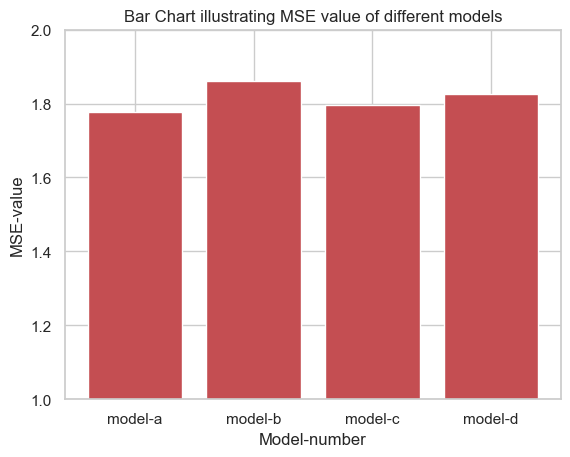

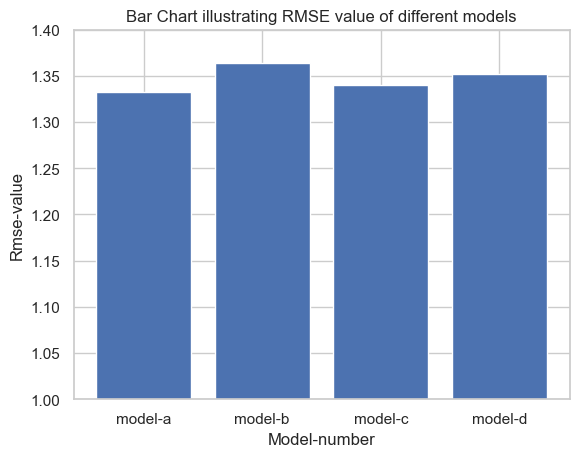

In [232]:
sns.set(style='whitegrid')
plt.ylim(1,2)
plt.title('Bar Chart illustrating MSE value of different models')
plt.xlabel('Model-number')
plt.ylabel('MSE-value')
plt.bar(data=mse_data,height='MSE', x=['model-a','model-b','model-c','model-d'], color = 'r')
plt.show()

sns.set(style = 'whitegrid')
plt.ylim(1,1.4)
plt.title('Bar Chart illustrating RMSE value of different models')
plt.xlabel('Model-number')
plt.ylabel('Rmse-value')
plt.bar(data=rmse_data,height = 'RMSE', x=['model-a','model-b','model-c','model-d'], color = 'b')
plt.show()

##### Assessment:
As evaluated earlier, it can be seen from the graphical illustration that the first bar from the left represented by Model-a, returns the lowest Mean Squared Error(MSE) and Root Mean Squared Error (RMSE) value, indicating a better performance of the model in temrs of prediction accuracy. Model-b (2nd bar from the left) returns the highest MSE and RMSE values, which indicates the worst performance of the models and the prediction will be least accurate.

Model-c (represented by the 3rd bar from the left) illustrates the 2nd lowest MSE and RMSE values. Hence, it can be considered the 2nd best model to perform after model-a. Model-d (represented by the bar on the right hand side) returns the 2nd largest values for MSE and RMSE.


### Data Science Ethics
*Please read the following examples [Click here to read the example_1.](https://www.vox.com/covid-19-coronavirus-us-response-trump/2020/5/18/21262265/georgia-covid-19-cases-declining-reopening) [Click here to read the example_2.](https://viborc.com/ethics-and-ethical-data-visualization-a-complete-guide/)

*Then view the picture ![My Image](figure_portfolio2.png "This is my image")
Please compose an analysis of 100-200 words that evaluates potential ethical concerns associated with the infographic, detailing the reasons behind these issues.


##### Analysis:
The differences between the countries are not highlighted, but rather order from highest to lowest is portrayed. This is an ethical concern of fairness and objectivity. A bar chart would portray that some of the countries are very close to each other in terms of number of medals and would give a more clear picture of the competitive landscape instead of just showing which country is ahead, which is slightly deceptive.

In Table 2, it can be seen that the table is slighty misleading in terms of fariness and objectivity, and also cherry picking a particular aspect: Gold medal. Illustrating that China is at Top. Whereas, the full picture and consideration of total medal shows that USA is at top. Moreover, it undermines the position of other countries like France and paints an overall deceptive picture of where each country stands.

Moreover, little information is given regarding the credibility of the source of the data. Additionally, there less input of aesthetics, as very bland typography and color fonts are used, making it difficult and time consuiming to interpret the data.